# YOLO adversarial patch analysis

Side-by-side comparison of YOLO detections on the leader CarlaCola:
- **clean**: original RGB frame from the paired `_clean` dataset (no marker)
- **trained**: paired `_marker` frame with our trained patch warped onto the quad

Bounding boxes / confidence are computed only for the leader vehicle (selected as the highest-confidence vehicle whose centroid falls inside the expanded marker bounding box). Frames where YOLO **already fails on clean** are excluded from the aggregate metrics — there's no meaningful 'delta' on a frame where confidence was already 0.

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == 'yolo_chroma_attack' else Path.cwd()

RUN_TS = '20260609_014138'
MARKER_DIR = REPO_ROOT / 'data' / 'chroma_key_dataset' / f'capture_{RUN_TS}_marker'
CLEAN_DIR = REPO_ROOT / 'data' / 'chroma_key_dataset' / f'capture_{RUN_TS}_clean'
QUADS = json.loads((MARKER_DIR / 'quads_index.json').read_text())

PATCH_RUN = REPO_ROOT / 'experiments' / 'yolo_attack' / 'run02_20260609_093207'
PATCH = torch.load(PATCH_RUN / 'patch_final.pt', map_location='cpu').clamp(0, 1)
print('patch shape:', tuple(PATCH.shape))

YOLO_WEIGHTS = REPO_ROOT / 'src' / 'vehicle_counting_model' / 'yolov8n.pt'
yolo = YOLO(str(YOLO_WEIGHTS))
COCO_NAMES = yolo.model.names
VEHICLE_CLASSES = {2: 'car', 5: 'bus', 7: 'truck'}
CONF_THRESHOLD = 0.25

stems = sorted(QUADS.keys())
print(f'{len(stems)} frames with detected marker quad')

/home/vortex/miniconda3/envs/PCLA310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patch shape: (3, 256, 512)
1793 frames with detected marker quad


In [2]:
def order_corners(c):
    c = np.asarray(c, np.float32)
    s = c.sum(1); d = np.diff(c, axis=1).reshape(-1)
    return np.stack([c[np.argmin(s)], c[np.argmin(d)], c[np.argmax(s)], c[np.argmax(d)]])

def target_bbox(corners, img_shape, expand=2.5):
    H, W = img_shape[:2]
    cx, cy = corners[:, 0].mean(), corners[:, 1].mean()
    hw = (corners[:, 0].max() - corners[:, 0].min()) * 0.5 * expand
    hh = (corners[:, 1].max() - corners[:, 1].min()) * 0.5 * expand
    return np.array([max(0, cx - hw), max(0, cy - hh),
                     min(W - 1, cx + hw), min(H - 1, cy + hh)], np.float32)

def warp_patch_onto(img_bgr, patch_chw, corners):
    """OpenCV perspective warp of the trained patch onto the marker quad."""
    Ph, Pw = patch_chw.shape[1], patch_chw.shape[2]
    patch_bgr = (patch_chw.permute(1, 2, 0).numpy()[..., ::-1] * 255).clip(0, 255).astype('uint8')
    src = np.array([[0, 0], [Pw - 1, 0], [Pw - 1, Ph - 1], [0, Ph - 1]], np.float32)
    dst = order_corners(corners)
    M = cv2.getPerspectiveTransform(src, dst)
    Hf, Wf = img_bgr.shape[:2]
    warped = cv2.warpPerspective(patch_bgr, M, (Wf, Hf))
    mask = np.ones((Ph, Pw), np.uint8) * 255
    warped_mask = cv2.warpPerspective(mask, M, (Wf, Hf))
    out = img_bgr.copy(); out[warped_mask > 0] = warped[warped_mask > 0]
    return out

def yolo_leader_detection(bgr, tbox):
    """Return (best_box xyxy or None, best_conf, best_class_name) for the leader.
    Picks the highest-confidence vehicle detection whose centroid lies inside the
    expanded marker target bbox."""
    res = yolo.predict(bgr, verbose=False, conf=CONF_THRESHOLD)[0]
    if res.boxes is None or len(res.boxes) == 0:
        return None, 0.0, None
    boxes = res.boxes.xyxy.cpu().numpy()
    confs = res.boxes.conf.cpu().numpy()
    clss = res.boxes.cls.cpu().int().tolist()
    cands = []
    for box, conf, cls in zip(boxes, confs, clss):
        if cls not in VEHICLE_CLASSES: continue
        cx = (box[0] + box[2]) / 2; cy = (box[1] + box[3]) / 2
        if tbox[0] <= cx <= tbox[2] and tbox[1] <= cy <= tbox[3]:
            cands.append((conf, box, cls))
    if not cands:
        return None, 0.0, None
    cands.sort(reverse=True, key=lambda t: t[0])
    return cands[0][1], float(cands[0][0]), VEHICLE_CLASSES[cands[0][2]]

## Aggregate metrics

Iterate all val-set frames (paired clean + patched), compute detection / confidence on both, then aggregate **excluding** frames where YOLO already misses the leader on clean.

In [3]:
# Use the same val split as training (deterministic 80/20, seed=0, sorted stems)
from random import Random
rng = Random(0)
all_stems = sorted(QUADS.keys())
rng.shuffle(all_stems)
n_val = int(0.2 * len(all_stems))
val_stems = sorted(all_stems[:n_val])
print(f'val set: {len(val_stems)} frames')

rows = []
for i, stem in enumerate(val_stems):
    if i % 50 == 0: print(f'  {i}/{len(val_stems)}', flush=True)
    clean_path = CLEAN_DIR / f'{stem}.png'
    marker_path = MARKER_DIR / f'{stem}.png'
    if not clean_path.exists() or not marker_path.exists():
        continue
    clean_bgr = cv2.imread(str(clean_path))
    marker_bgr = cv2.imread(str(marker_path))
    corners = np.asarray(QUADS[stem]['corners'], np.float32)
    tbox = target_bbox(corners, clean_bgr.shape, expand=2.5)
    patched_bgr = warp_patch_onto(marker_bgr, PATCH, corners)
    
    _, conf_clean, cls_clean = yolo_leader_detection(clean_bgr, tbox)
    _, conf_patched, cls_patched = yolo_leader_detection(patched_bgr, tbox)
    rows.append({
        'stem': stem,
        'conf_clean': conf_clean, 'cls_clean': cls_clean,
        'conf_patched': conf_patched, 'cls_patched': cls_patched,
        'leader_visible_clean': conf_clean > 0,
        'leader_visible_patched': conf_patched > 0,
    })
df = pd.DataFrame(rows)
print(f'total frames evaluated: {len(df)}')
df.head()

val set: 358 frames
  0/358


  50/358


  100/358


  150/358


  200/358


  250/358


  300/358


  350/358


total frames evaluated: 358


,stem,conf_clean,cls_clean,conf_patched,cls_patched,leader_visible_clean,leader_visible_patched
0,000006,0.000000,None,0.0,None,False,False
1,000009,0.321144,truck,0.0,None,True,False
2,000012,0.000000,None,0.0,None,False,False
3,000022,0.000000,None,0.0,None,False,False
4,000024,0.424763,truck,0.0,None,True,False


In [4]:
# ---- Metrics ----
n_total = len(df)
n_clean_seen = int(df['leader_visible_clean'].sum())
n_clean_blind = n_total - n_clean_seen

df_seen = df[df['leader_visible_clean']].copy()
n_seen = len(df_seen)
n_seen_hidden_by_patch = int((~df_seen['leader_visible_patched']).sum())

mean_conf_clean_seen = df_seen['conf_clean'].mean()
mean_conf_patched_seen = df_seen['conf_patched'].mean()
delta_abs = mean_conf_patched_seen - mean_conf_clean_seen
delta_pct = 100 * delta_abs / mean_conf_clean_seen

# Detection rate including frames already-blind
det_rate_clean_all = df['leader_visible_clean'].mean()
det_rate_patched_all = df['leader_visible_patched'].mean()
# Detection rate excluding already-blind
det_rate_clean_seen = 1.0
det_rate_patched_seen = df_seen['leader_visible_patched'].mean()

metrics = pd.DataFrame({
    'metric': [
        'val frames total',
        'leader VISIBLE in clean',
        'leader ALREADY BLIND in clean (excluded)',
        '— on visible-in-clean only —',
        'mean conf clean (excl. blind)',
        'mean conf with patch (excl. blind)',
        'absolute delta',
        'relative delta',
        'detections lost (visible → invisible)',
        '— including blind frames —',
        'det rate clean (all)',
        'det rate patched (all)',
    ],
    'value': [
        f'{n_total}',
        f'{n_clean_seen} ({100*n_clean_seen/n_total:.1f}%)',
        f'{n_clean_blind} ({100*n_clean_blind/n_total:.1f}%)',
        '',
        f'{mean_conf_clean_seen:.4f}',
        f'{mean_conf_patched_seen:.4f}',
        f'{delta_abs:+.4f}',
        f'{delta_pct:+.2f}%',
        f'{n_seen_hidden_by_patch}/{n_seen} ({100*n_seen_hidden_by_patch/n_seen:.1f}%)',
        '',
        f'{100*det_rate_clean_all:.1f}%',
        f'{100*det_rate_patched_all:.1f}%',
    ],
})
metrics

,metric,value
0,val frames total,358
1,leader VISIBLE in clean,284 (79.3%)
2,leader ALREADY BLIND in clean (excluded),74 (20.7%)
3,— on visible-in-clean only —,
4,mean conf clean (excl. blind),0.6030
5,mean conf with patch (excl. blind),0.4895
6,absolute delta,-0.1135
7,relative delta,-18.83%
8,detections lost (visible → invisible),51/284 (18.0%)
9,— including blind frames —,


In [5]:
# Did the patch change the predicted CLASS for the leader (besides confidence)?
from collections import Counter
clean_cls = Counter(df_seen['cls_clean'])
patched_cls = Counter(df_seen['cls_patched'].fillna('<NONE>'))
cls_df = pd.DataFrame({
    'class': sorted(set(list(clean_cls) + list(patched_cls))),
    'clean': [clean_cls.get(k, 0) for k in sorted(set(list(clean_cls) + list(patched_cls)))],
    'patched': [patched_cls.get(k, 0) for k in sorted(set(list(clean_cls) + list(patched_cls)))],
})
cls_df

,class,clean,patched
0,<NONE>,0,51
1,bus,34,75
2,car,48,53
3,truck,202,105


In [ ]:
# Visualize the trained patch: evolution across epochs + final result in large.
import matplotlib.image as mpimg
import re
patch_dir = REPO_ROOT / 'experiments/yolo_attack/run02_20260609_093207'
checkpoints = sorted(patch_dir.glob('patch_ep*.png'), key=lambda p: int(re.findall(r'ep(\d+)', p.name)[0]))
print(f'Found {len(checkpoints)} epoch checkpoints')
# Pick 10 evenly-spaced epochs to show the trajectory (1, ~10, ~20, ..., last)
if len(checkpoints) >= 10:
    idx = np.linspace(0, len(checkpoints) - 1, 10).astype(int)
    selected = [checkpoints[i] for i in idx]
else:
    selected = checkpoints

if selected:
    fig, axes = plt.subplots(2, 5, figsize=(20, 5))
    axes = axes.reshape(-1)
    for ax, png in zip(axes, selected):
        ax.imshow(mpimg.imread(png))
        ep = int(re.findall(r'ep(\d+)', png.name)[0])
        ax.set_title(f'epoch {ep}', fontsize=10)
        ax.axis('off')
    for ax in axes[len(selected):]:
        ax.axis('off')
    plt.suptitle('Patch evolution across training (run02 - 100 epochs, cosine LR)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Final patch in big
    final = patch_dir / 'patch_final.png'
    if final.exists():
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(mpimg.imread(final))
        ax.set_title(f'Final trained patch (run02, 100 epochs)  -  shape 256x512 RGB  -  AR=2.0 matching the chroma-key marker', fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f'No checkpoint PNGs found in {patch_dir}. (They live on the training machine only.)')

## Side-by-side comparison frames

For each row: **clean** (left, YOLO box in green) | **with patch** (right, YOLO box in red if still detected, none if hidden).

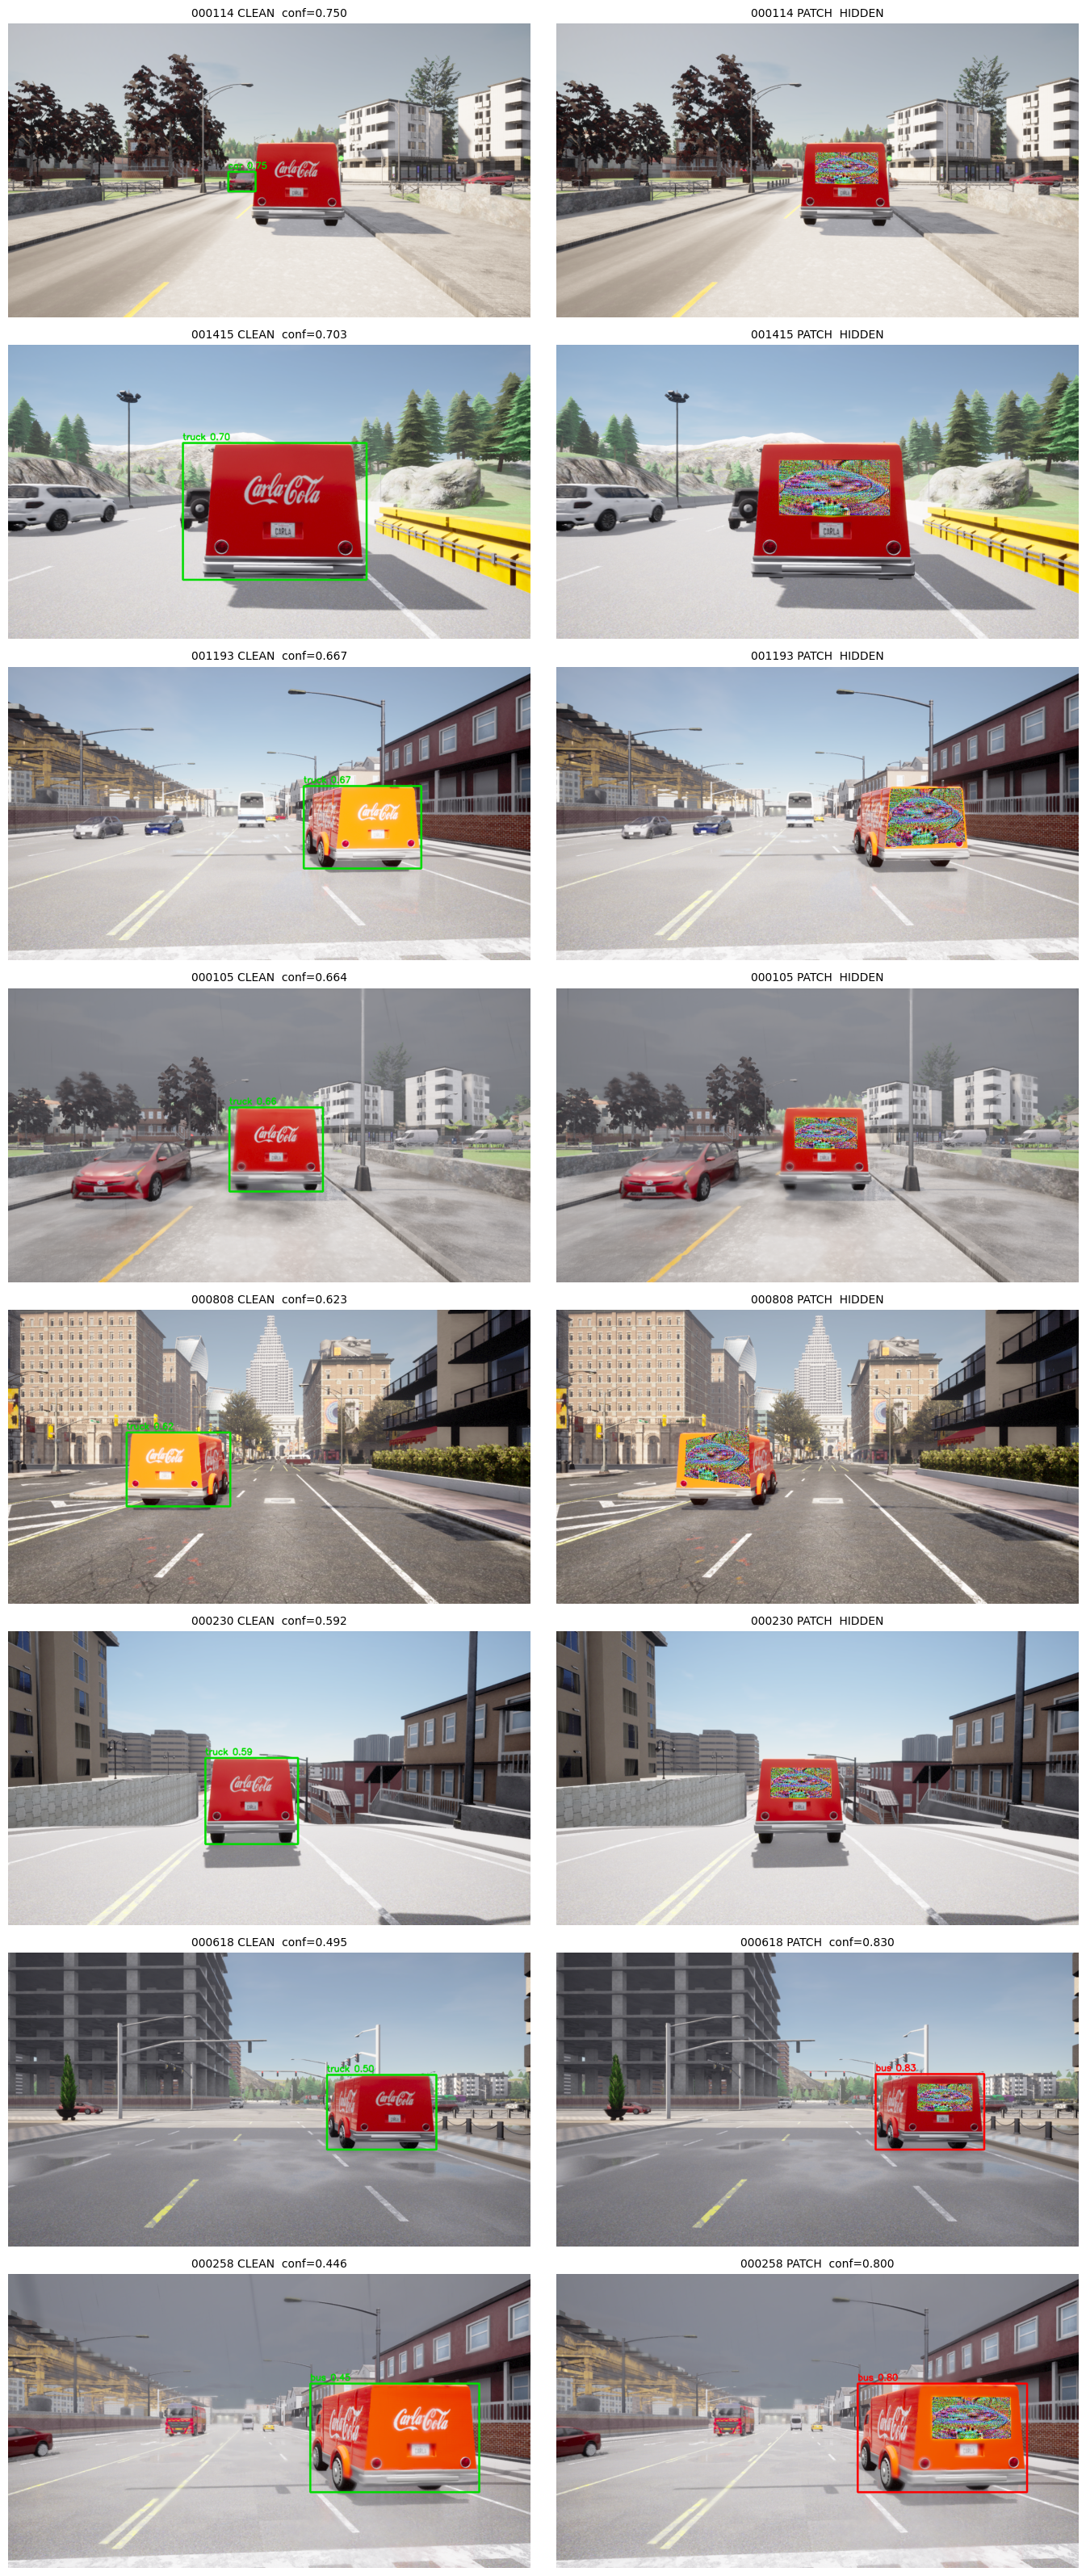

In [6]:
def draw_yolo_box(bgr, box, conf, cls, color):
    img = bgr.copy()
    if box is None: return img
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img, f'{cls} {conf:.2f}', (x1, max(0, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img

def show_pair(stem, ax_clean, ax_patched):
    clean_bgr = cv2.imread(str(CLEAN_DIR / f'{stem}.png'))
    marker_bgr = cv2.imread(str(MARKER_DIR / f'{stem}.png'))
    corners = np.asarray(QUADS[stem]['corners'], np.float32)
    tbox = target_bbox(corners, clean_bgr.shape, expand=2.5)
    patched_bgr = warp_patch_onto(marker_bgr, PATCH, corners)
    box_c, conf_c, cls_c = yolo_leader_detection(clean_bgr, tbox)
    box_p, conf_p, cls_p = yolo_leader_detection(patched_bgr, tbox)
    img_c = draw_yolo_box(clean_bgr, box_c, conf_c, cls_c or 'none', (0, 220, 0))
    img_p = draw_yolo_box(patched_bgr, box_p, conf_p, cls_p or 'HIDDEN', (0, 0, 255))
    ax_clean.imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))
    ax_clean.set_title(f'{stem} CLEAN  conf={conf_c:.3f}', fontsize=10)
    ax_clean.axis('off')
    ax_patched.imshow(cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB))
    title = f'{stem} PATCH  '
    title += f'conf={conf_p:.3f}' if conf_p > 0 else 'HIDDEN'
    ax_patched.set_title(title, fontsize=10)
    ax_patched.axis('off')

def show_pairs(stems_list, cols=2):
    n = len(stems_list)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1: axes = np.array([axes])
    for row, stem in enumerate(stems_list):
        show_pair(stem, axes[row, 0], axes[row, 1])
    plt.tight_layout()
    plt.show()

# Pick 8 example frames, biased toward big drops + a few where the patch failed
df_seen_sorted = df_seen.copy()
df_seen_sorted['drop'] = df_seen_sorted['conf_clean'] - df_seen_sorted['conf_patched']
df_seen_sorted = df_seen_sorted.sort_values('drop', ascending=False)
examples = list(df_seen_sorted.head(6)['stem']) + list(df_seen_sorted.tail(2)['stem'])
show_pairs(examples)

## Legend & how to read the plots

**Side-by-side bounding boxes:**
- **Green box** = YOLO detection on the CLEAN image (left column). Conf shown next to label.
- **Red box** = YOLO detection on the PATCHED image (right column).
- Colors mark *which image*, NOT direction of confidence change. A bigger red conf than green conf means the patch actually MADE THE DETECTION STRONGER for that frame (failure case — intentionally shown for the last 2 rows of side-by-side).
- If no box on the patched side: the leader is **hidden** — that's the success case for the attack.

**Histograms (left):** stacked distribution of YOLO confidence on the leader, for the *visible-in-clean* subset.  Green = clean confidence, red = patched.  Heavy overlap means the patch is shifting the distribution but not flattening it (lots of frames still detected, just with lower conf).

**Paired scatter (right):** each point is **one frame**, x = its clean conf, y = its conf with the patch.  The dashed diagonal `y = x` is the 'no effect' line — every point exactly on it would mean the patch did nothing.  Points BELOW the diagonal = patch reduced confidence (success).  Points ABOVE = patch *increased* confidence (failure, e.g. class confusion truck→bus with high conf).  Points squashed at y=0 = leader fully hidden by the patch.


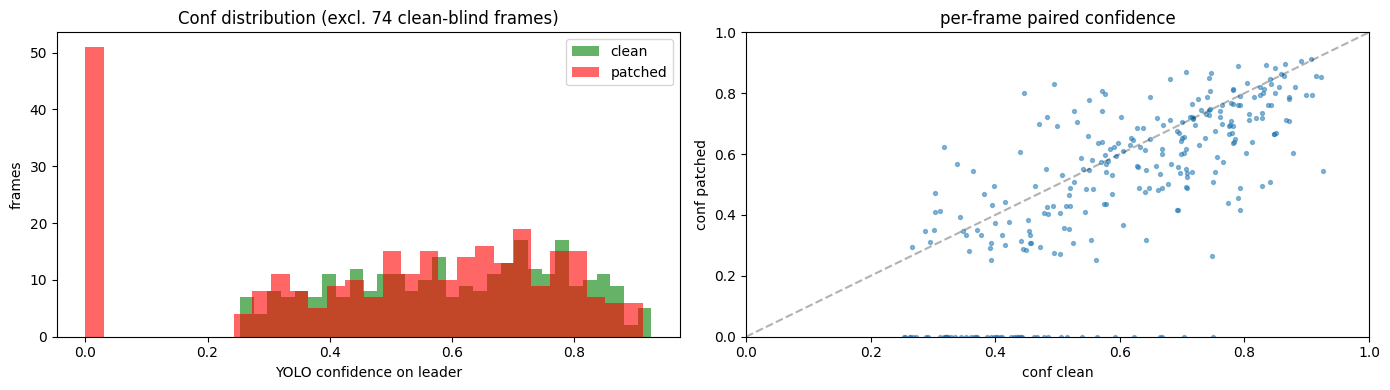

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_seen['conf_clean'], bins=30, alpha=0.6, label='clean', color='green')
axes[0].hist(df_seen['conf_patched'], bins=30, alpha=0.6, label='patched', color='red')
axes[0].set_xlabel('YOLO confidence on leader')
axes[0].set_ylabel('frames')
axes[0].set_title(f'Conf distribution (excl. {n_clean_blind} clean-blind frames)')
axes[0].legend()
axes[1].scatter(df_seen['conf_clean'], df_seen['conf_patched'], s=8, alpha=0.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('conf clean')
axes[1].set_ylabel('conf patched')
axes[1].set_title('per-frame paired confidence')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()